```
# =============================================================================
# Integrantes: Arthur Meneses Neves, Danilo Oliveira Santos, Matheus Gabriel
# Viana Araujo, João Victor Vidal Barbosa, Guilherme Araujo Castro
#
# Síntese: Resultados parciais da N1: baseline de classe majoritária, Random Forest e
# XGBoost para classificar o capítulo CID-10 da causa de óbito a partir de
# variáveis sociodemográficas (SIM 2000-2026). Nenhum campo da cadeia de causas
# do atestado (LINHAA-D, CIRCOBITO) é usado como entrada. A divisão
# treino/teste é estratificada; o recorte por ano (treino até 2022, teste em
# 2023, 2025 e 2026) é só uma checagem à parte.
#
# Changelog:
#   2026-09-23 - Matheus Araujo - criação do notebook
#   2026-09-23 - Matheus Araujo - correção das afirmações sobre recall
#   2026-09-24 - Matheus Araujo - discussão (d)(iii): supressão de grupos pequenos
#   2026-09-25 - Matheus Araujo - protocolo: motivo de codmun6 e ano ficarem fora das entradas
# =============================================================================
```

# Resultados parciais: baseline vs. Random Forest vs. XGBoost

**Problema.** Classificar o capítulo da CID-10 da causa básica de óbito (19 classes observadas, ver seção 1) a partir de cinco variáveis sociodemográficas do atestado: idade, sexo, raça/cor, escolaridade e UF de residência.

**Protocolo (definido antes de treinar):**

1. **Dados:** `sim_utils.carregar_df_modelo` (mesma preparação do notebook `02_preparacao_dados.ipynb`, com cache), SIM 2000-2026, Brasil.
2. **Entradas e rótulo:** vêm das constantes `FEATURE_COLUMNS` e `TARGET_COLUMN` de `src/sim_utils.py`. Município fino (`codmun6`) e ano não são entradas (o município entra só como UF). Nenhum campo da cadeia de causas (`LINHAA`-`LINHAD`, `CIRCOBITO`, `CAUSABAS_O`) é entrada nem chega a ser lido, para não vazar o rótulo.
3. **Divisão principal:** treino/teste 80/20 **estratificada por classe** (`random_state=42`). O conjunto de teste é o mesmo para os três modelos e nunca é subamostrado.
4. **Codificação:** *one-hot* denso em `float32` das quatro variáveis categóricas; `idade_anos` entra como número. O codificador é ajustado só no treino.
5. **Desbalanceamento:** pesos de amostra balanceados (`compute_sample_weight("balanced")`), iguais para Random Forest e XGBoost.
6. **Modelos:** baseline de classe majoritária (`DummyClassifier`), Random Forest e XGBoost (`tree_method="hist"`), todos treinados na base de treino completa.
7. **Métricas:** F1-macro, recall por classe (todas as classes) e matriz de confusão (normalizada por linha). A acurácia aparece só como referência.
8. **Checagem suplementar:** generalização temporal (treino ≤2022, teste 2023, 2025 e 2026), separada do protocolo principal.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import sklearn
import xgboost

sys.path.insert(0, str(Path.cwd().parent / "src"))
from sim_utils import FEATURE_COLUMNS, TARGET_COLUMN, carregar_df_modelo

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

SEED = 42
ANOS = list(range(2000, 2027))  # 1979-1999 fora de escopo (CID-9)
NOMES_CURTOS = {
    "I": "infecciosas", "II": "neoplasias", "III": "sangue/imunit.", "IV": "endócrinas",
    "V": "mentais", "VI": "nervoso", "VII": "olho", "VIII": "ouvido",
    "IX": "circulatório", "X": "respiratório", "XI": "digestivo", "XII": "pele",
    "XIII": "osteomuscular", "XIV": "geniturinário", "XV": "gravidez/parto",
    "XVI": "perinatal", "XVII": "malformações", "XVIII": "mal definidas",
    "XX": "causas externas",
}
print(f"scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__} | pandas {pd.__version__}")

scikit-learn 1.9.1 | xgboost 3.4.1 | pandas 3.0.6


## 1. Dados, número de classes e desbalanceamento

In [2]:
t0 = time.perf_counter()
df = carregar_df_modelo("../data", ANOS, "../data/cache")
print(f"Carga: {time.perf_counter() - t0:.1f} s | {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"Anos: {df['ano_arquivo'].min()}-{df['ano_arquivo'].max()} ({df['ano_arquivo'].nunique()} arquivos)")

contagem = df[TARGET_COLUMN].astype(str).value_counts()
distribuicao = pd.DataFrame({"n": contagem, "%": (100 * contagem / contagem.sum()).round(4)})
distribuicao.insert(0, "descrição", [NOMES_CURTOS[c] for c in distribuicao.index])
print()
print(distribuicao.to_string())

n_classes = contagem.size
maior, menor = contagem.idxmax(), contagem.idxmin()
razao_desbalanceamento = contagem.max() / contagem.min()
print()
print(f"Número de classes (capítulos CID-10 observados): {n_classes}")
print(f"Classe majoritária: {maior} ({NOMES_CURTOS[maior]}) = {contagem.max():,} linhas, {100 * contagem.max() / contagem.sum():.2f}%")
print(f"Classe minoritária: {menor} ({NOMES_CURTOS[menor]}) = {contagem.min():,} linhas, {100 * contagem.min() / contagem.sum():.4f}%")
print(f"Razão de desbalanceamento (maior / menor): {razao_desbalanceamento:,.0f}x")
print(f"Classes com menos de 0,5% das linhas: {(100 * contagem / contagem.sum() < 0.5).sum()}")
print(f"Acurácia de um classificador que sempre prevê '{maior}': {contagem.max() / contagem.sum():.4f}")

# A divisão estratificada precisa de pelo menos 2 linhas por classe
assert contagem.min() >= 2, "classe com menos de 2 linhas: split estratificado impossível"

Carga: 0.5 s | 32,531,918 linhas x 8 colunas
Anos: 2000-2026 (27 arquivos)



                      descrição        n        %
capitulo_cid10                                   
IX                 circulatório  8788199  27.0141
II                   neoplasias  5108490  15.7030
XX              causas externas  3712335  11.4114
X                  respiratório  3516512  10.8094
XVIII             mal definidas  2328478   7.1575
I                   infecciosas  2108449   6.4812
IV                   endócrinas  1896126   5.8285
XI                    digestivo  1614124   4.9617
XIV               geniturinário   879273   2.7028
VI                      nervoso   854902   2.6279
XVI                   perinatal   632965   1.9457
V                       mentais   336307   1.0338
XVII               malformações   271194   0.8336
III              sangue/imunit.   165129   0.5076
XII                        pele   134961   0.4149
XIII              osteomuscular   132556   0.4075
XV               gravidez/parto    46798   0.1439
VIII                     ouvido     4491   0.0138

## 2. Entradas sem vazamento de rótulo e divisão estratificada (protocolo principal)

O conjunto de entradas vem de `FEATURE_COLUMNS` (importado de `sim_utils`) e o rótulo de `TARGET_COLUMN`; as colunas não são listadas de novo aqui. A célula abaixo confere que nenhuma coluna de entrada é o rótulo, o município fino, o ano, nem um campo da cadeia de causas.

In [3]:
print("Entradas (FEATURE_COLUMNS):", FEATURE_COLUMNS)
print("Rótulo (TARGET_COLUMN):   ", TARGET_COLUMN)

proibidas = {"codmun6", "ano_arquivo", TARGET_COLUMN, "CAUSABAS", "CAUSABAS_O", "CIRCOBITO"}
assert proibidas.isdisjoint(FEATURE_COLUMNS)
assert not any(c.upper().startswith("LINHA") for c in FEATURE_COLUMNS)
assert not any(c.upper().startswith("LINHA") for c in df.columns), "coluna LINHA* presente no frame"
print("Colunas do frame de modelagem:", list(df.columns))
print("OK: nenhuma entrada revela a causa de óbito direta ou indiretamente.")

X = df[FEATURE_COLUMNS].copy()
X["idade_anos"] = X["idade_anos"].astype("float32")  # mantém a matriz final em float32
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COLUMN].astype(str))
assert len(le.classes_) == n_classes
rotulos = [f"{c} {NOMES_CURTOS[c]}" for c in le.classes_]

idx_treino, idx_teste = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y,
)
y_treino, y_teste = y[idx_treino], y[idx_teste]
X_treino, X_teste = X.iloc[idx_treino], X.iloc[idx_teste]

print(f"\nTreino: {len(idx_treino):,} | Teste: {len(idx_teste):,} (80/20, estratificado por classe, random_state={SEED})")
prop_treino = np.bincount(y_treino, minlength=n_classes) / len(y_treino)
prop_teste = np.bincount(y_teste, minlength=n_classes) / len(y_teste)
print(f"Maior diferença absoluta de proporção de classe entre treino e teste: {np.abs(prop_treino - prop_teste).max():.2e}")
suporte_teste = pd.Series(np.bincount(y_teste, minlength=n_classes), index=le.classes_, name="suporte_teste")
print()
print(suporte_teste.to_string())

Entradas (FEATURE_COLUMNS): ['idade_anos', 'sexo', 'racacor', 'escolaridade', 'uf']
Rótulo (TARGET_COLUMN):    capitulo_cid10
Colunas do frame de modelagem: ['idade_anos', 'sexo', 'racacor', 'escolaridade', 'uf', 'codmun6', 'ano_arquivo', 'capitulo_cid10']
OK: nenhuma entrada revela a causa de óbito direta ou indiretamente.



Treino: 26,025,534 | Teste: 6,506,384 (80/20, estratificado por classe, random_state=42)
Maior diferença absoluta de proporção de classe entre treino e teste: 8.52e-08

I         421690
II       1021698
III        33026
IV        379225
IX       1757640
V          67261
VI        170980
VII          126
VIII         898
X         703302
XI        322825
XII        26992
XIII       26511
XIV       175855
XV          9360
XVI       126593
XVII       54239
XVIII     465696
XX        742467


## 3. Pré-processamento e pesos de amostra

In [4]:
preprocessador = ColumnTransformer(
    [
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32),
            [c for c in FEATURE_COLUMNS if c != "idade_anos"],
        ),
        ("idade", "passthrough", ["idade_anos"]),
    ],
    sparse_threshold=0,
)
X_treino_prep = preprocessador.fit_transform(X_treino)  # ajustado só no treino
X_teste_prep = preprocessador.transform(X_teste)
nomes_colunas = preprocessador.get_feature_names_out()
print(f"X_treino_prep: {X_treino_prep.shape} {X_treino_prep.dtype} ({X_treino_prep.nbytes / 1e9:.1f} GB)")
print(f"X_teste_prep:  {X_teste_prep.shape} {X_teste_prep.dtype} ({X_teste_prep.nbytes / 1e9:.1f} GB)")
print(f"Número de colunas após o one-hot: {len(nomes_colunas)}")

pesos_treino = compute_sample_weight(class_weight="balanced", y=y_treino)
peso_por_classe = pd.Series(pesos_treino, index=y_treino).groupby(level=0).first()
peso_por_classe.index = le.classes_
print()
print("Peso de amostra balanceado por classe (n_treino / (n_classes * n_classe)):")
print(peso_por_classe.round(4).to_string())
print(f"Razão entre o maior e o menor peso: {peso_por_classe.max() / peso_por_classe.min():,.0f}x")

del X_treino, X_teste  # libera memória

X_treino_prep: (26025534, 42) float32 (4.4 GB)
X_teste_prep:  (6506384, 42) float32 (1.1 GB)
Número de colunas após o one-hot: 42



Peso de amostra balanceado por classe (n_treino / (n_classes * n_classe)):
I           0.8121
II          0.3352
III        10.3689
IV          0.9030
IX          0.1948
V           5.0912
VI          2.0028
VII      2723.1908
VIII      381.2315
X           0.4869
XI          1.0608
XII        12.6867
XIII       12.9168
XIV         1.9473
XV         36.5876
XVI         2.7051
XVII        6.3136
XVIII       0.7353
XX          0.4612
Razão entre o maior e o menor peso: 13,977x


**Escolhas de implementação (justificativas).** O *one-hot* denso em `float32` ocupa poucos GB e evita a conversão de matriz esparsa dentro do Random Forest do scikit-learn e do XGBoost. O `XGBClassifier` usa `tree_method="hist"` (histogramas por *bin*), que é o método adequado para dezenas de milhões de linhas. O `num_class` do XGBoost é `n_classes`, calculado dos dados. Nenhum hiperparâmetro foi ajustado: os valores abaixo são configurações iniciais, com os mesmos pesos de amostra para os dois modelos, e o ajuste fino fica para a N2.

## 4. Funções de avaliação

In [5]:
resultados = {}  # nome -> dict(pred, tempo_s)


def avaliar(nome, y_pred, tempo_s):
    resultados[nome] = {
        "pred": y_pred,
        "tempo_s": tempo_s,
        "f1_macro": f1_score(y_teste, y_pred, average="macro", zero_division=0),
        "acuracia": accuracy_score(y_teste, y_pred),
        "recall_por_classe": recall_score(y_teste, y_pred, average=None, labels=range(n_classes), zero_division=0),
    }
    r = resultados[nome]
    print(f"{nome}: treinado em {tempo_s:.1f} s | F1-macro = {r['f1_macro']:.4f} | acurácia = {r['acuracia']:.4f}")
    print(classification_report(y_teste, y_pred, labels=range(n_classes), target_names=rotulos, zero_division=0, digits=3))


def plotar_matriz_confusao(nome):
    fig, ax = plt.subplots(figsize=(13, 11))
    ConfusionMatrixDisplay.from_predictions(
        y_teste, resultados[nome]["pred"], labels=range(n_classes), display_labels=rotulos,
        normalize="true", values_format=".2f", cmap="Blues", ax=ax, xticks_rotation=90,
        text_kw={"fontsize": 6},
    )
    ax.set_title(f"{nome}: matriz de confusão normalizada por linha (= recall na diagonal)")
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe verdadeira")
    fig.tight_layout()
    plt.show()

## 5. Baseline: classe majoritária

In [6]:
t0 = time.perf_counter()
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_treino_prep, y_treino)
tempo_baseline = time.perf_counter() - t0
avaliar("Baseline (classe majoritária)", baseline.predict(X_teste_prep), tempo_baseline)

Baseline (classe majoritária): treinado em 3.1 s | F1-macro = 0.0224 | acurácia = 0.2701


                     precision    recall  f1-score   support

      I infecciosas      0.000     0.000     0.000    421690
      II neoplasias      0.000     0.000     0.000   1021698
 III sangue/imunit.      0.000     0.000     0.000     33026
      IV endócrinas      0.000     0.000     0.000    379225
    IX circulatório      0.270     1.000     0.425   1757640
          V mentais      0.000     0.000     0.000     67261
         VI nervoso      0.000     0.000     0.000    170980
           VII olho      0.000     0.000     0.000       126
        VIII ouvido      0.000     0.000     0.000       898
     X respiratório      0.000     0.000     0.000    703302
       XI digestivo      0.000     0.000     0.000    322825
           XII pele      0.000     0.000     0.000     26992
 XIII osteomuscular      0.000     0.000     0.000     26511
  XIV geniturinário      0.000     0.000     0.000    175855
  XV gravidez/parto      0.000     0.000     0.000      9360
      XVI perinatal    

## 6. Random Forest (100 árvores, profundidade máxima 12, pesos balanceados)

In [7]:
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
rf.fit(X_treino_prep, y_treino, sample_weight=pesos_treino)
tempo_rf = time.perf_counter() - t0
avaliar("Random Forest", rf.predict(X_teste_prep), tempo_rf)

Random Forest: treinado em 343.9 s | F1-macro = 0.1329 | acurácia = 0.1625


                     precision    recall  f1-score   support

      I infecciosas      0.105     0.022     0.037    421690
      II neoplasias      0.284     0.176     0.218   1021698
 III sangue/imunit.      0.013     0.000     0.001     33026
      IV endócrinas      0.100     0.155     0.122    379225
    IX circulatório      0.365     0.001     0.003   1757640
          V mentais      0.026     0.301     0.047     67261
         VI nervoso      0.067     0.279     0.108    170980
           VII olho      0.000     0.079     0.000       126
        VIII ouvido      0.000     0.028     0.001       898
     X respiratório      0.178     0.110     0.136    703302
       XI digestivo      0.085     0.076     0.080    322825
           XII pele      0.009     0.099     0.016     26992
 XIII osteomuscular      0.007     0.089     0.014     26511
  XIV geniturinário      0.051     0.059     0.055    175855
  XV gravidez/parto      0.039     0.970     0.074      9360
      XVI perinatal    

## 7. XGBoost (100 rodadas, profundidade 6, `tree_method="hist"`, pesos balanceados)

In [8]:
t0 = time.perf_counter()
xgb = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    objective="multi:softmax", num_class=n_classes,
    tree_method="hist", random_state=SEED, n_jobs=-1,
)
xgb.fit(X_treino_prep, y_treino, sample_weight=pesos_treino)
tempo_xgb = time.perf_counter() - t0
avaliar("XGBoost", xgb.predict(X_teste_prep), tempo_xgb)

XGBoost: treinado em 983.3 s | F1-macro = 0.1406 | acurácia = 0.1755


                     precision    recall  f1-score   support

      I infecciosas      0.118     0.028     0.045    421690
      II neoplasias      0.277     0.247     0.261   1021698
 III sangue/imunit.      0.015     0.006     0.008     33026
      IV endócrinas      0.105     0.149     0.123    379225
    IX circulatório      0.374     0.026     0.049   1757640
          V mentais      0.033     0.306     0.060     67261
         VI nervoso      0.070     0.277     0.111    170980
           VII olho      0.000     0.048     0.000       126
        VIII ouvido      0.001     0.077     0.001       898
     X respiratório      0.183     0.101     0.130    703302
       XI digestivo      0.091     0.080     0.085    322825
           XII pele      0.009     0.124     0.016     26992
 XIII osteomuscular      0.008     0.045     0.014     26511
  XIV geniturinário      0.053     0.102     0.070    175855
  XV gravidez/parto      0.039     0.975     0.074      9360
      XVI perinatal    

## 8. Comparação: F1-macro, acurácia (referência) e custo de treino

In [9]:
nomes = ["Baseline (classe majoritária)", "Random Forest", "XGBoost"]
comparacao = pd.DataFrame(
    {
        "modelo": nomes,
        "f1_macro": [resultados[n]["f1_macro"] for n in nomes],
        "acuracia": [resultados[n]["acuracia"] for n in nomes],
        "recall_macro": [resultados[n]["recall_por_classe"].mean() for n in nomes],
        "tempo_treino_s": [resultados[n]["tempo_s"] for n in nomes],
    }
).set_index("modelo")
comparacao["tempo_treino_min"] = comparacao["tempo_treino_s"] / 60
print(comparacao.round(4).to_string())
print()
f1b, f1r, f1x = (comparacao.loc[n, "f1_macro"] for n in nomes)
print(f"F1-macro: RF - baseline = {f1r - f1b:+.4f} | XGBoost - baseline = {f1x - f1b:+.4f} | XGBoost - RF = {f1x - f1r:+.4f}")
print(f"Razão F1-macro RF / baseline = {f1r / f1b:.1f}x | XGBoost / baseline = {f1x / f1b:.1f}x")
print(f"Razão de tempo de treino XGBoost / RF = {comparacao.loc['XGBoost', 'tempo_treino_s'] / comparacao.loc['Random Forest', 'tempo_treino_s']:.2f}x")
comparacao.round(4)

                               f1_macro  acuracia  recall_macro  tempo_treino_s  tempo_treino_min
modelo                                                                                           
Baseline (classe majoritária)    0.0224    0.2701        0.0526          3.1398            0.0523
Random Forest                    0.1329    0.1625        0.2234        343.9412            5.7324
XGBoost                          0.1406    0.1755        0.2294        983.2612           16.3877

F1-macro: RF - baseline = +0.1105 | XGBoost - baseline = +0.1183 | XGBoost - RF = +0.0078
Razão F1-macro RF / baseline = 5.9x | XGBoost / baseline = 6.3x
Razão de tempo de treino XGBoost / RF = 2.86x


,f1_macro,acuracia,recall_macro,tempo_treino_s,tempo_treino_min
modelo,,,,,
Baseline (classe majoritária),0.0224,0.2701,0.0526,3.1398,0.0523
Random Forest,0.1329,0.1625,0.2234,343.9412,5.7324
XGBoost,0.1406,0.1755,0.2294,983.2612,16.3877


## 9. Recall por classe (todas as 19 classes) nos três modelos

In [10]:
recall_tabela = pd.DataFrame(
    {
        "descrição": [NOMES_CURTOS[c] for c in le.classes_],
        "suporte_teste": suporte_teste.values,
        "baseline": resultados[nomes[0]]["recall_por_classe"],
        "RF": resultados[nomes[1]]["recall_por_classe"],
        "XGB": resultados[nomes[2]]["recall_por_classe"],
    },
    index=le.classes_,
)
recall_tabela.index.name = "capítulo"
print(recall_tabela.round(4).to_string())
print()
for col in ["baseline", "RF", "XGB"]:
    zeros = list(recall_tabela.index[recall_tabela[col] == 0])
    print(f"{col}: {len(zeros)} classes com recall 0 -> {zeros}")
raras = recall_tabela.loc[["VII", "VIII", "XV"]]
print()
print("Capítulos raros (VII olho, VIII ouvido, XV gravidez/parto):")
print(raras.round(4).to_string())
recall_tabela.round(4)

                descrição  suporte_teste  baseline      RF     XGB
capítulo                                                          
I             infecciosas         421690       0.0  0.0224  0.0281
II             neoplasias        1021698       0.0  0.1765  0.2473
III        sangue/imunit.          33026       0.0  0.0004  0.0058
IV             endócrinas         379225       0.0  0.1546  0.1491
IX           circulatório        1757640       1.0  0.0013  0.0260
V                 mentais          67261       0.0  0.3006  0.3058
VI                nervoso         170980       0.0  0.2794  0.2767
VII                  olho            126       0.0  0.0794  0.0476
VIII               ouvido            898       0.0  0.0278  0.0768
X            respiratório         703302       0.0  0.1099  0.1011
XI              digestivo         322825       0.0  0.0763  0.0805
XII                  pele          26992       0.0  0.0987  0.1236
XIII        osteomuscular          26511       0.0  0.0886  0.

,descrição,suporte_teste,baseline,RF,XGB
capítulo,,,,,
I,infecciosas,421690,0.0,0.0224,0.0281
II,neoplasias,1021698,0.0,0.1765,0.2473
III,sangue/imunit.,33026,0.0,0.0004,0.0058
IV,endócrinas,379225,0.0,0.1546,0.1491
IX,circulatório,1757640,1.0,0.0013,0.0260
V,mentais,67261,0.0,0.3006,0.3058
VI,nervoso,170980,0.0,0.2794,0.2767
VII,olho,126,0.0,0.0794,0.0476
VIII,ouvido,898,0.0,0.0278,0.0768


## 10. Matrizes de confusão (uma figura por modelo, normalizadas por linha)

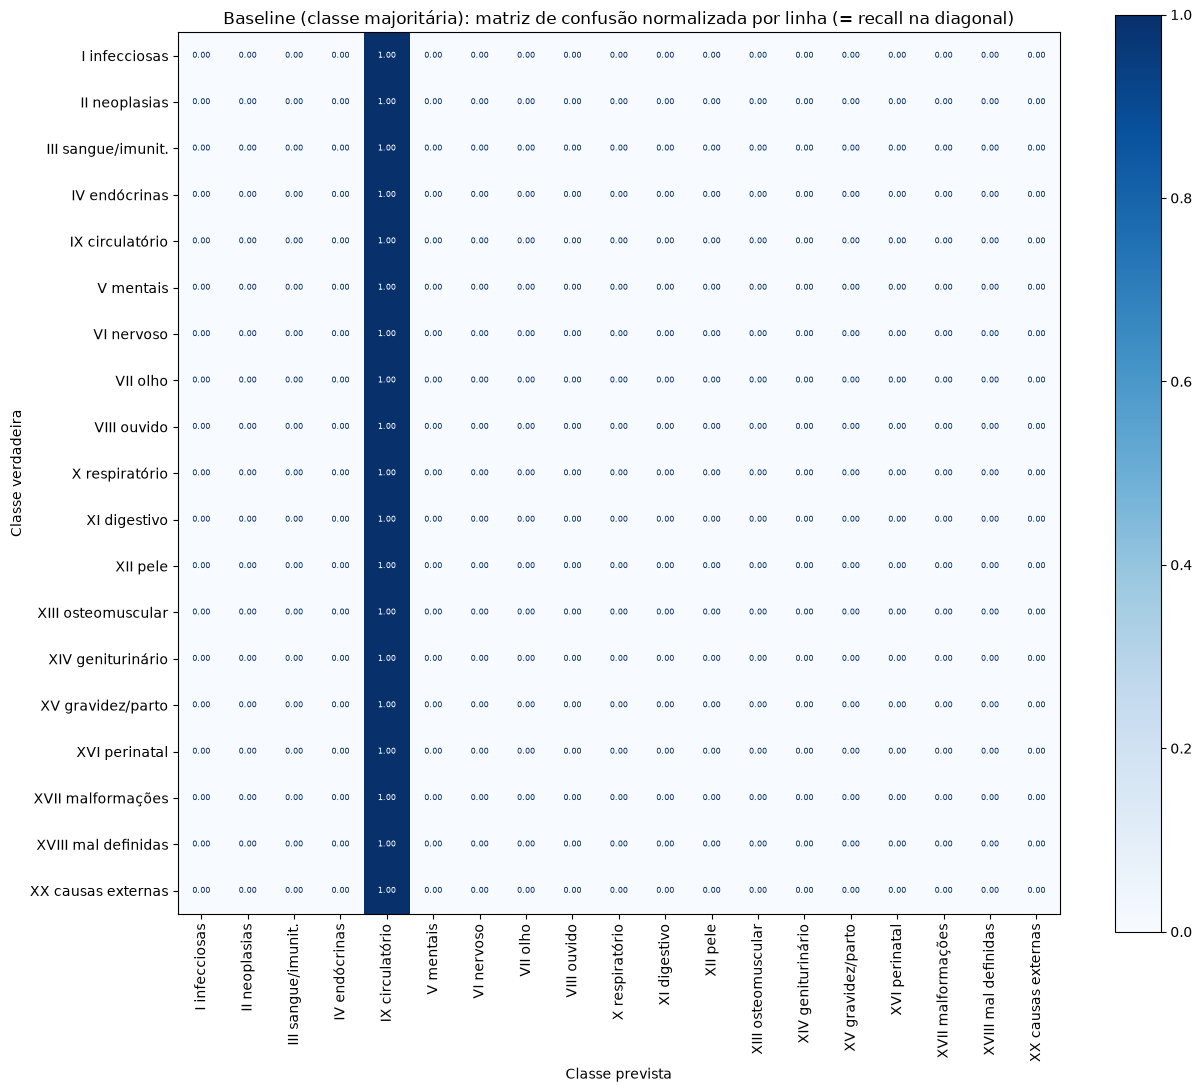

In [11]:
plotar_matriz_confusao('Baseline (classe majoritária)')

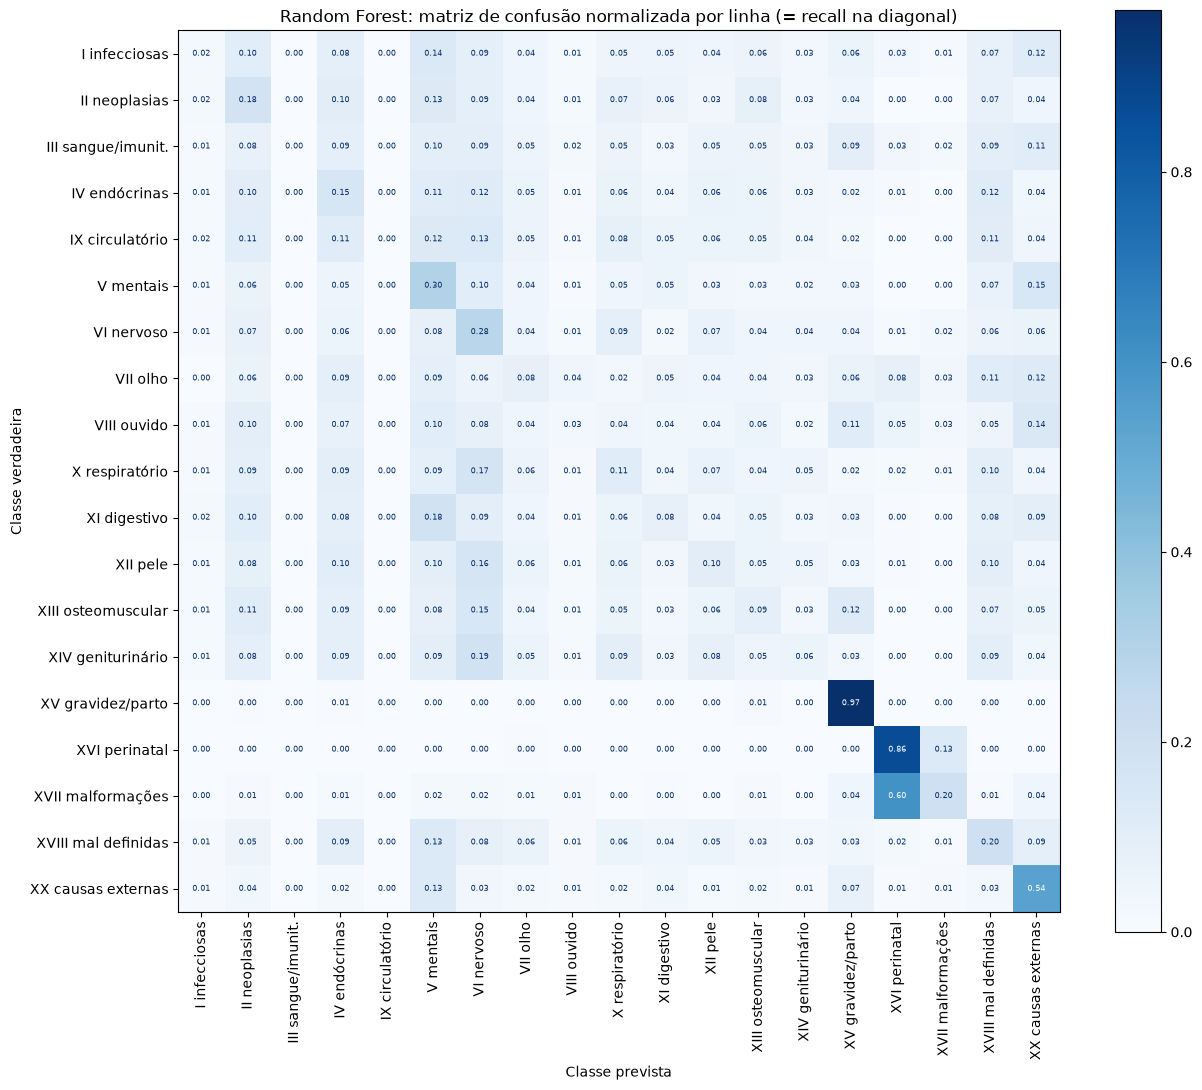

In [12]:
plotar_matriz_confusao('Random Forest')

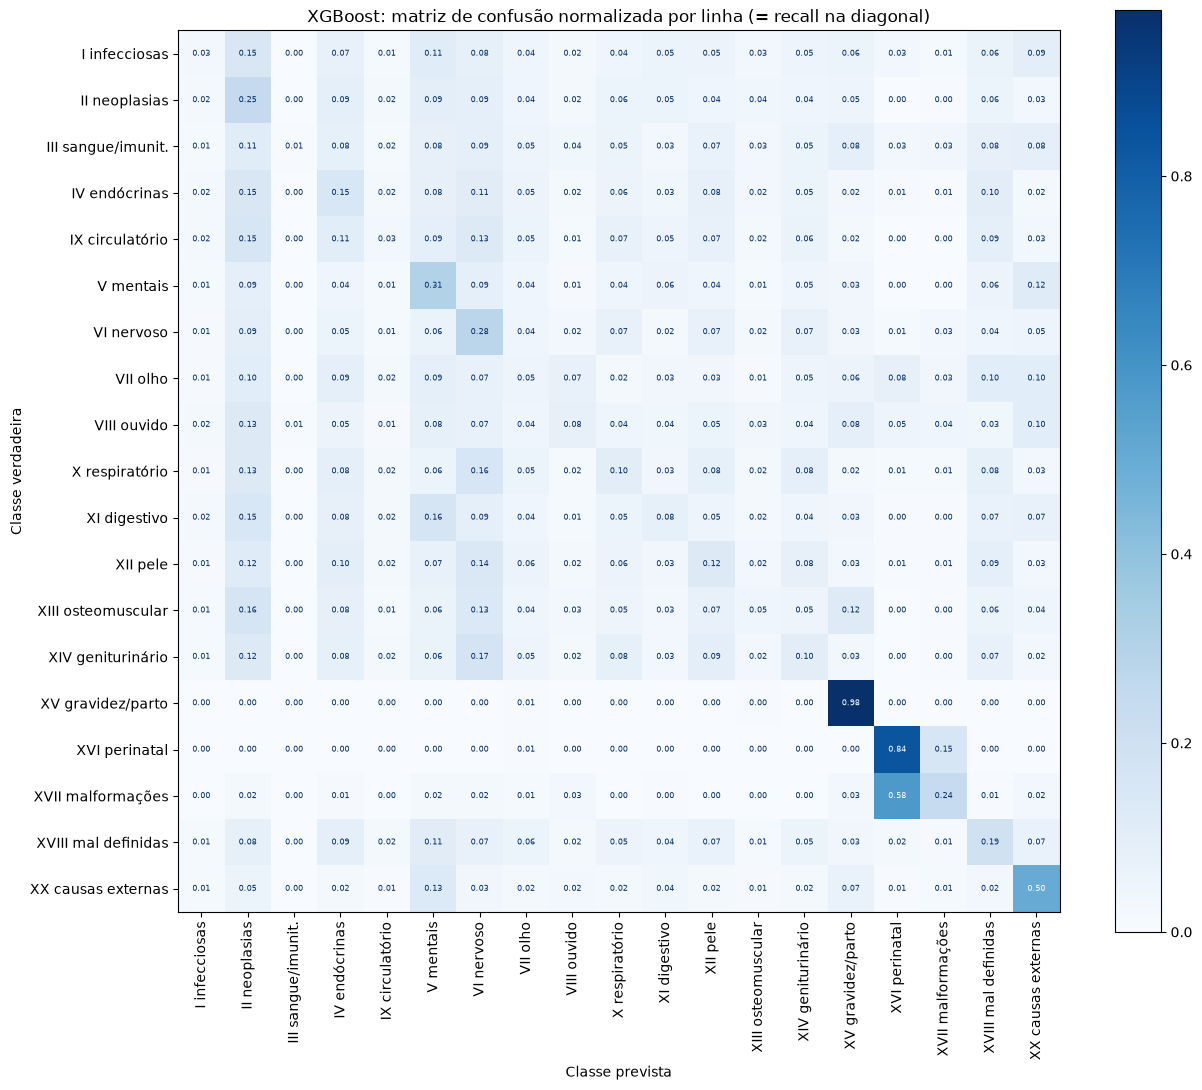

In [13]:
plotar_matriz_confusao('XGBoost')

### Capítulos raros (VII, VIII e XV) e leitura das matrizes de confusão

As matrizes são normalizadas por linha: a diagonal é o recall da classe e cada linha soma 1. Só assim as classes raras aparecem; em contagens absolutas, a linha do capítulo VII (126 casos no teste) sumiria ao lado do capítulo IX (1.757.640).

- **VII (olho), 126 casos de teste.** O Random Forest acerta 10 (recall 0,0794) e o XGBoost 6 (0,0476). A precisão é praticamente zero nos dois (0,000), coerente com o peso de 2.723 dado a essa classe (seção 3): o modelo passa a prever VII para muitas linhas de outras classes. Com 126 casos, a diferença entre 10 e 6 acertos não permite dizer qual modelo é melhor aqui.
- **VIII (ouvido), 898 casos.** O Random Forest acerta 25 (0,0278) e o XGBoost 69 (0,0768); precisão de 0,000 (RF) e 0,001 (XGBoost).
- **XV (gravidez, parto e puerpério), 9.360 casos.** É a classe mais fácil de reconhecer (recall 0,9701 no RF e 0,9754 no XGBoost), mesmo sendo rara. Provavelmente porque idade e sexo quase determinam a classe (mulheres em idade fértil), mas a precisão segue baixa (0,039 nos dois), já que muitas mulheres jovens morrem de outras causas.
- Nenhum capítulo foi fundido ou removido: os 19 aparecem com seu recall. Para VII e VIII os números são só indicativos, pelo tamanho do suporte.
- Os capítulos XV e XVI (perinatal) têm recall acima de 0,5 nos dois modelos; XX (causas externas) passa de 0,5 só no Random Forest (0,5363 contra 0,4975 no XGBoost). Na matriz do Random Forest, 60% dos casos de XVII (malformações congênitas) são previstos como XVI (perinatal), o que faz sentido, pois as duas causas se concentram nas primeiras idades. Os capítulos I, II, III, IV, IX, X, XI, XII, XIII e XIV têm recall abaixo de 0,25 nos dois modelos, e as previsões se espalham entre eles.

## 11. Checagem suplementar: generalização temporal (treino ≤2022, teste 2023/2025/2026)

Esta checagem **não substitui** a divisão estratificada. Ela responde outra pergunta: o modelo generaliza para anos que nunca viu, e não só para linhas sorteadas dos mesmos anos? Usa o mesmo conjunto de cinco entradas, o pré-processador já ajustado (o *one-hot* é fixo: 4 categóricas com valores conhecidos) e os mesmos hiperparâmetros e pesos balanceados, recalculados no treino temporal. O ano 2024 não entra nem no treino (só até 2022) nem no teste (2023, 2025 e 2026), e 2026 é um **ano parcial** (o arquivo tem bem menos óbitos que um ano completo). O F1-macro por ano é calculado sobre as classes que aparecem no ano (verdadeiras ou previstas).

In [14]:
del X_treino_prep, X_teste_prep, pesos_treino  # libera memória antes do recorte temporal
ANOS_TREINO_TEMPORAL = list(range(2000, 2023))
ANOS_TESTE_TEMPORAL = [2023, 2025, 2026]
mask_treino_t = df["ano_arquivo"].isin(ANOS_TREINO_TEMPORAL).values
mask_teste_t = df["ano_arquivo"].isin(ANOS_TESTE_TEMPORAL).values
assert not (mask_treino_t & mask_teste_t).any()

X_treino_t = preprocessador.transform(X[mask_treino_t])
X_teste_t = preprocessador.transform(X[mask_teste_t])
y_treino_t, y_teste_t = y[mask_treino_t], y[mask_teste_t]
ano_teste_t = df.loc[mask_teste_t, "ano_arquivo"].values
pesos_treino_t = compute_sample_weight("balanced", y_treino_t)
print(f"Treino temporal (2000-2022): {len(y_treino_t):,} linhas | classes presentes: {np.unique(y_treino_t).size}")
print(f"Teste temporal (2023, 2025, 2026): {len(y_teste_t):,} linhas")
print(f"Amostras por ano de teste: {dict(zip(*np.unique(ano_teste_t, return_counts=True)))}")

modelos_t = {}
tempos_t = {}
t0 = time.perf_counter()
rf_t = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
rf_t.fit(X_treino_t, y_treino_t, sample_weight=pesos_treino_t)
tempos_t["Random Forest"] = time.perf_counter() - t0
modelos_t["Random Forest"] = rf_t

t0 = time.perf_counter()
xgb_t = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    objective="multi:softmax", num_class=n_classes,
    tree_method="hist", random_state=SEED, n_jobs=-1,
)
xgb_t.fit(X_treino_t, y_treino_t, sample_weight=pesos_treino_t)
tempos_t["XGBoost"] = time.perf_counter() - t0
modelos_t["XGBoost"] = xgb_t
print({k: f"{v:.1f} s" for k, v in tempos_t.items()})

linhas = []
for nome_modelo, modelo in modelos_t.items():
    pred = modelo.predict(X_teste_t)
    for ano in ANOS_TESTE_TEMPORAL:
        m = ano_teste_t == ano
        linhas.append(
            {
                "modelo": nome_modelo,
                "ano_teste": ano,
                "n_linhas": int(m.sum()),
                "classes_no_ano": int(np.unique(np.concatenate([y_teste_t[m], pred[m]])).size),
                "f1_macro": f1_score(y_teste_t[m], pred[m], average="macro", zero_division=0),
                "acuracia": accuracy_score(y_teste_t[m], pred[m]),
            }
        )
    linhas.append(
        {
            "modelo": nome_modelo, "ano_teste": "2023+2025+2026", "n_linhas": len(y_teste_t),
            "classes_no_ano": int(np.unique(np.concatenate([y_teste_t, pred])).size),
            "f1_macro": f1_score(y_teste_t, pred, average="macro", zero_division=0),
            "acuracia": accuracy_score(y_teste_t, pred),
        }
    )
temporal = pd.DataFrame(linhas)
print()
print(temporal.round(4).to_string(index=False))
print()
print("Referência (protocolo principal, divisão estratificada 80/20):")
print(comparacao.loc[["Random Forest", "XGBoost"], ["f1_macro", "acuracia"]].round(4).to_string())
temporal.round(4)

Treino temporal (2000-2022): 27,506,105 linhas | classes presentes: 19
Teste temporal (2023, 2025, 2026): 3,495,855 linhas
Amostras por ano de teste: {np.int16(2023): np.int64(1463485), np.int16(2025): np.int64(1526343), np.int16(2026): np.int64(506027)}


{'Random Forest': '352.9 s', 'XGBoost': '1322.3 s'}



       modelo      ano_teste  n_linhas  classes_no_ano  f1_macro  acuracia
Random Forest           2023   1463485              19    0.1253    0.1370
Random Forest           2025   1526343              19    0.1216    0.1298
Random Forest           2026    506027              19    0.1202    0.1290
Random Forest 2023+2025+2026   3495855              19    0.1230    0.1327
      XGBoost           2023   1463485              19    0.1340    0.1538
      XGBoost           2025   1526343              19    0.1297    0.1464
      XGBoost           2026    506027              19    0.1287    0.1463
      XGBoost 2023+2025+2026   3495855              19    0.1314    0.1495

Referência (protocolo principal, divisão estratificada 80/20):
               f1_macro  acuracia
modelo                           
Random Forest    0.1329    0.1625
XGBoost          0.1406    0.1755


,modelo,ano_teste,n_linhas,classes_no_ano,f1_macro,acuracia
0,Random Forest,2023,1463485,19,0.1253,0.1370
1,Random Forest,2025,1526343,19,0.1216,0.1298
2,Random Forest,2026,506027,19,0.1202,0.1290
3,Random Forest,2023+2025+2026,3495855,19,0.1230,0.1327
4,XGBoost,2023,1463485,19,0.1340,0.1538
5,XGBoost,2025,1526343,19,0.1297,0.1464
6,XGBoost,2026,506027,19,0.1287,0.1463
7,XGBoost,2023+2025+2026,3495855,19,0.1314,0.1495


**Resultado da checagem temporal.** Nos dois modelos o F1-macro cai pouco e de forma contínua de 2023 para 2025 e 2026: Random Forest 0,1253, 0,1216 e 0,1202 (queda de 0,0051 até 2026); XGBoost 0,1340, 0,1297 e 0,1287 (queda de 0,0053). A queda é pequena perto da distância até o baseline, mas existe. O F1-macro do teste temporal (RF 0,1230; XGBoost 0,1314) também fica cerca de 0,01 abaixo do protocolo principal (RF 0,1329; XGBoost 0,1406). Essa comparação não isola deriva temporal: o treino temporal tem outro tamanho (27.506.105 linhas contra 26.025.534) e o teste é um conjunto diferente de anos, com outra mistura de classes. O baseline não foi recalculado nesta checagem. Uma possível causa é a mudança na qualidade do preenchimento de raça/cor e escolaridade ao longo dos anos (notebook 01), mas isso não foi testado. Em 2026 há 506.027 linhas, contra 1.463.485 (2023) e 1.526.343 (2025), porque o arquivo do ano é parcial; as classes raras têm poucos casos e o F1-macro do ano é menos estável. O XGBoost fica acima do RF em todos os anos (diferença entre 0,0081 e 0,0087).

## 12. Discussão dos resultados parciais

Os números abaixo vêm das saídas executadas neste notebook (divisão estratificada 80/20, teste com 6.506.384 linhas, uma única execução com `random_state=42`).

**(a) Classes, desbalanceamento e pesos.** Foram observados 19 capítulos CID-10 (XIX e XXI nunca aparecem como causa básica). A maior classe, IX (circulatório), tem 8.788.199 linhas (27,01%); a menor, VII (olho), tem 629 (0,0019%), uma razão de 13.972x, e 5 capítulos têm menos de 0,5% das linhas. Por isso os dois modelos usam pesos de amostra balanceados, com razão de 13.977x entre o maior (2.723,19 para VII) e o menor (0,1948 para IX). Sem pesos, a perda seria dominada pelas classes grandes, mas não rodamos essa versão para confirmar. O custo dos pesos aparece nos resultados: o recall do capítulo IX cai a 0,0013 (RF) e 0,0260 (XGBoost), e a acurácia fica em 0,1625 e 0,1755, abaixo dos 0,2701 do baseline. Em troca, nenhuma classe tem recall exatamente zero nos modelos (o baseline zera 18 das 19), embora III (0,0004) e IX (0,0013) fiquem quase em zero no Random Forest, e o recall médio sobe de 0,0526 para 0,2234 (RF) e 0,2294 (XGBoost). Como o objetivo é reconhecer todos os capítulos, o critério principal é o F1-macro e a acurácia entra só como referência. Outro efeito é a precisão baixa nas classes raras (seção 9).

**(b) XGBoost contra Random Forest: o ganho compensa o custo?** O XGBoost teve F1-macro de 0,1406 contra 0,1329 do Random Forest (+0,0078, cerca de 6% em termos relativos) e levou 983,3 s (16,4 min) contra 343,9 s (5,7 min) de treino, ou seja, 2,86x mais tempo, ambos com `n_jobs=-1`. Na checagem temporal a razão foi maior (1.322,3 s contra 352,9 s, cerca de 3,7x). O ganho é pequeno em valor absoluto: o XGBoost vai melhor em alguns capítulos (II: recall 0,2473 contra 0,1765; XIV: 0,1022 contra 0,0593; IX: 0,0260 contra 0,0013) e o Random Forest em outros (XVI: 0,8602 contra 0,8373; XX: 0,5363 contra 0,4975; XIII: 0,0886 contra 0,0454). As configurações iniciais são diferentes (profundidade 12 e 6) e nenhuma foi ajustada, então a comparação não diz qual família é melhor depois do ajuste. Por ora o Random Forest é mais barato e chega perto; o XGBoost só compensa se o ajuste de hiperparâmetros na N2 ampliar a vantagem, o que ainda precisa ser verificado.

**(c) Margem sobre o baseline.** Em F1-macro, o Random Forest supera o baseline em +0,1105 (0,1329 contra 0,0224, 5,9x) e o XGBoost em +0,1183 (0,1406, 6,3x). Os dois também ganham em recall médio, mas o baseline vence em acurácia (0,2701). O valor absoluto é baixo: um F1-macro de 0,13 a 0,14 quer dizer que a maioria dos capítulos é reconhecida de forma fraca, e só XV e XVI passam de 0,5 de recall nos dois modelos (XX passa apenas no Random Forest).

**(d) Limites e o que a N2 precisaria.** Com cinco variáveis sociodemográficas (idade, sexo, raça/cor, escolaridade e UF), um resultado modesto era esperado: elas separam bem as causas ligadas à idade e ao sexo (XV e XVI, e em menor grau XX), mas pouco as causas de adultos e idosos, que são a maioria dos óbitos. Para um modelo melhor seriam necessários atributos que hoje estão fora do conjunto: (i) variáveis clínicas ou de circunstância do óbito que não revelem a causa (por exemplo, local de ocorrência e assistência médica, desde que se confirme que não vazam o rótulo); (ii) variáveis temporais, como mês e ano do óbito; (iii) variáveis do município (porte, IDH, cobertura de saúde) em vez de só a UF, com agregação suficiente para respeitar a supressão de grupos pequenos adotada pelo grupo (princípio de minimização da LGPD); e (iv) ajuste de hiperparâmetros, limiares por classe e, se o grupo decidir, agrupamento dos capítulos muito raros ou análise por faixa etária. Limites deste experimento: uma única divisão e uma única semente (sem intervalo de confiança), modelos sem ajuste, e avaliação dos capítulos VII e VIII baseada em 126 e 898 casos de teste.